In [12]:
# --- 1. Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
accuracy_score,
roc_auc_score,
confusion_matrix,
classification_report,
RocCurveDisplay
)

In [2]:
path = "./credit_risk_dataset.csv"
df = pd.read_csv(path)


print("Dataset shape:", df.shape)
df.head()

Dataset shape: (500, 8)


,income,debt_to_income_ratio,credit_utilization,late_payments,loan_amount,employment_length,age,default
0,59571.0,0.255,0.725,3,11960.0,22,37,0
1,39400.0,0.134,0.943,0,1000.0,29,72,0
2,66257.0,0.380,0.528,1,21717.0,3,22,0
3,69108.0,0.116,0.644,0,26480.0,13,36,0
4,25734.0,0.251,0.322,0,26921.0,7,28,0


In [3]:
print("\nData types:\n", df.dtypes)
print("\nMissing values per column:\n", df.isna().sum())


Data types:
 income                  float64
debt_to_income_ratio    float64
credit_utilization      float64
late_payments             int64
loan_amount             float64
employment_length         int64
age                       int64
default                   int64
dtype: object

Missing values per column:
 income                  0
debt_to_income_ratio    0
credit_utilization      0
late_payments           0
loan_amount             0
employment_length       0
age                     0
default                 0
dtype: int64


In [4]:
print("\nTarget distribution:")
print(df['default'].value_counts(normalize=True))


Target distribution:
default
0    0.99
1    0.01
Name: proportion, dtype: float64


In [5]:
df.describe()

,income,debt_to_income_ratio,credit_utilization,late_payments,loan_amount,employment_length,age,default
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000
mean,54803.108000,0.323968,0.504356,1.186000,15525.374000,13.70800,48.236000,0.010000
std,14399.023399,0.162420,0.262527,1.081547,7865.150799,9.15261,15.382378,0.099598
min,16500.000000,0.051000,0.050000,0.000000,1000.000000,0.00000,21.000000,0.000000
25%,44996.000000,0.183750,0.269000,0.000000,9700.250000,5.00000,36.000000,0.000000
50%,55048.000000,0.319500,0.495500,1.000000,15065.500000,14.00000,48.000000,0.000000
75%,63810.750000,0.467250,0.733000,2.000000,21179.000000,22.00000,62.000000,0.000000
max,98708.000000,0.599000,0.949000,6.000000,39476.000000,30.00000,74.000000,1.000000


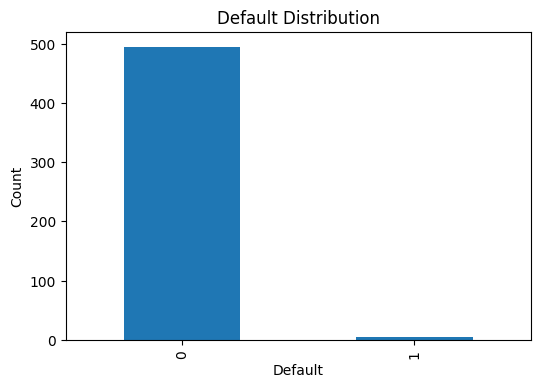

In [6]:
# --- 5. Simple visual exploration ---
plt.figure(figsize=(6,4))
df['default'].value_counts().plot(kind='bar')
plt.title('Default Distribution')
plt.xlabel('Default')
plt.ylabel('Count')
plt.show()

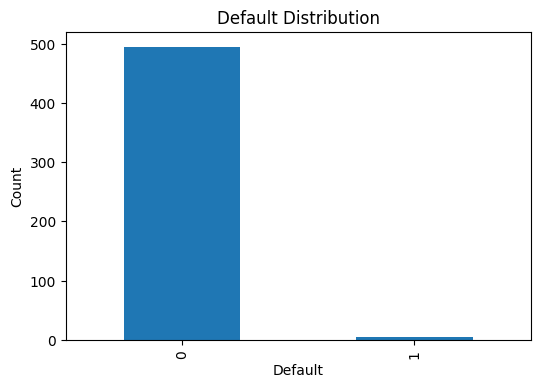

In [7]:
# --- 5. Simple visual exploration ---
plt.figure(figsize=(6,4))
df['default'].value_counts().plot(kind='bar')
plt.title('Default Distribution')
plt.xlabel('Default')
plt.ylabel('Count')
plt.show()

<Figure size 600x400 with 0 Axes>

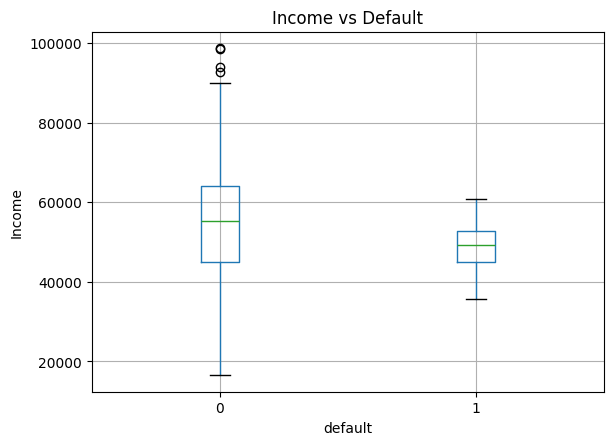

In [8]:
# Income vs default
plt.figure(figsize=(6,4))
df.boxplot(column='income', by='default')
plt.title('Income vs Default')
plt.suptitle('')
plt.ylabel('Income')
plt.show()

In [9]:
# --- 6. Feature / target split ---
X = df.drop(columns=['default'])
y = df['default']

In [13]:
# --- 6. Feature / target split ---
X = df.drop(columns=['default'])
y = df['default']

In [14]:
# --- 7. Train / test split ---
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.25, random_state=42, stratify=y
)

In [ ]:
# --- 8. Scaling (important for logistic regression) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Model and scaler saved.


In [34]:
# --- 9. Logistic Regression model ---
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [42]:
import joblib

joblib.dump(model, "logistic_credit_model.joblib")
joblib.dump(scaler, "credit_scaler.joblib")

print("Model and scaler saved.")


Model and scaler saved.


In [35]:
# --- 10. Predictions ---
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [36]:
# --- 11. Evaluation ---
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.992
ROC AUC: 0.5403225806451613

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       124
           1       0.00      0.00      0.00         1

    accuracy                           0.99       125
   macro avg       0.50      0.50      0.50       125
weighted avg       0.98      0.99      0.99       125



c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [37]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[124   0]
 [  1   0]]


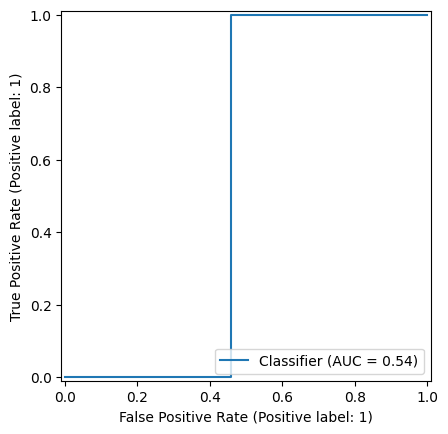

In [38]:
# ROC curve
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.show()

In [39]:
# --- 12. Coefficient analysis (interpretability) ---
coefficients = pd.DataFrame({
'feature': X.columns,
'coefficient': model.coef_[0]
}).sort_values(by='coefficient', ascending=False)

In [40]:
# --- 12. Coefficient analysis (interpretability) ---
coefficients = pd.DataFrame({
'feature': X.columns,
'coefficient': model.coef_[0]
}).sort_values(by='coefficient', ascending=False)
print("Feature Coefficients:\n", coefficients)

Feature Coefficients:
                 feature  coefficient
4           loan_amount     0.578437
3         late_payments     0.559074
1  debt_to_income_ratio     0.466423
6                   age     0.243516
5     employment_length    -0.179454
2    credit_utilization    -0.314304
0                income    -0.361662


In [41]:
# --- 13. Interpretation notes ---
print("""
Interpretation guide:
- Positive coefficients increase default risk
- Negative coefficients decrease default risk
- Odds ratio > 1 increases odds of default
- Odds ratio < 1 decreases odds of default


This dataset was generated with a linear-logistic ground truth,
so logistic regression is expected to perform very well.
""")


Interpretation guide:
- Positive coefficients increase default risk
- Negative coefficients decrease default risk
- Odds ratio > 1 increases odds of default
- Odds ratio < 1 decreases odds of default


This dataset was generated with a linear-logistic ground truth,
so logistic regression is expected to perform very well.

